**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 2 (Quadratic Approx)](02_quadratic_laplace_approximation.ipynb) | **Sheet 3 of 4: First Principles** | [➡️ Next: Sheet 4 (Production MCMC)](04_mcmc_production_diagnostics.ipynb)

---

# Sheet 3: The Mechanics of MCMC: How Random Walks Find Truth
### *The Pure First-Principles Bridge (Zero External Libraries)*

In **Sheet 1**, we saw that Grid Approximation cannot scale past 3 parameters. In **Sheet 2**, we saw that Quadratic Approximation scales to many parameters but assumes a symmetric Gaussian bell curve, failing on skewed or complex geometries.

Now, we arrive at the crown jewel of modern Bayesian computation: **Markov Chain Monte Carlo (MCMC)**.

This notebook builds an MCMC engine from absolute first principles using **pure Python (zero libraries)**. You will discover how a blind, memoryless random walker can explore an arbitrary parameter space and guarantee convergence to the exact posterior distribution.

---

## Table of Contents
1. **Part 1: The Intuition — King Markov and the Island Kingdom**
2. **Part 2: The Core Mathematics of Metropolis-Hastings**
   - **Deep Dive 1**: The Cancellation of the Intractable Denominator $P(y)$
   - **Deep Dive 2**: Detailed Balance & Stationary Distributions (The Proof of Convergence)
   - **Deep Dive 3**: The 3-Step Metropolis Algorithm (Propose $\to$ Ratio $\to$ Stochastic Decision)
3. **Part 3: 1D Metropolis from Scratch in Pure Python**
   - Implementing `metropolis_step()` and `run_mcmc()`
   - Traceplot, Running Mean & Posterior Histogram
4. **Part 4: The Step-Size ($\tau$) Dilemma & Tuning Failure Modes**
   - Mode 1: Step Size Too Small (Sluggish Diffusion & High Autocorrelation)
   - Mode 2: Step Size Too Large (Frozen Flatlines in Probability Deserts)
   - Mode 3: Optimal Step Size (Gelman's 23.4% – 44% Rule & Healthy Mixing)
5. **Part 5: Autocorrelation, Markov Memory Decay & Effective Sample Size ($ESS$)**
   - **Deep Dive 4**: What is Autocorrelation in MCMC?
   - Inspecting Decay via autocorrelation analysis
   - Effective Sample Size ($ESS$) Formula
   - The Truth About Thinning (When is it Useful?)
6. **Part 6: Joint 2D Metropolis from Scratch: Estimating Mean ($\mu$) and Spread ($\sigma$)**
   - Joint 2D Random Walk on Adult Heights
   - Comparing Grid vs. Laplace vs. MCMC Posteriors
7. **Part 7: The Curse of Volume & The Need for Hamiltonian Monte Carlo (HMC)**
8. **Part 8: Hands-On Challenge Exercises**

## Part 1: The Intuition — King Markov and the Island Kingdom

Imagine a benevolent monarch—**King Markov**—ruling an archipelago of islands arranged in a circle. Each island has a different population:
- Island 1 has 1,000 citizens.
- Island 2 has 2,000 citizens.
- Island 7 has 7,000 citizens.

The King wants to spend his time visiting each island in **exact proportion to its population** (spending 7 times as much time on Island 7 as on Island 1). However, the King is blindfolded, has no map of the kingdom, and does not know the total population of all islands combined.

### The King's Daily Protocol:
Every day, King Markov uses a simple rule:
1. **Flip a coin** to choose a neighboring island to visit (left or right).
2. **Send a royal scout** to measure the population of the candidate island ($P_{\text{prop}}$) and compare it to current island ($P_{\text{curr}}$).
3. **The Decision Rule**:
   - If the candidate island has **more people** ($P_{\text{prop}} > P_{\text{curr}}$), the King **always moves** there!
   - If the candidate island has **fewer people**, he moves with probability $\alpha = \frac{P_{\text{prop}}}{P_{\text{curr}}}$. He spins a wheel of fortune: with probability $\alpha$ he moves; otherwise, he stays put and drinks tea for another day on his current island.

> **The Miracle**: Over a year of recording his daily location, the King's visit history will match the island populations **with 100% mathematical precision**—without ever knowing the total population of the kingdom!

## Part 2: The Core Mathematics of Metropolis-Hastings

### Deep Dive 1: Cancellation of the Intractable Denominator

Recall Bayes' Theorem:
$$P(\theta \mid y) = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{P(y)} = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{\int \mathcal{L}(y \mid \theta) P(\theta) \, d\theta}$$

In higher dimensions, calculating the evidence integral $P(y) = \int \mathcal{L} \cdot P \, d\theta$ is practically impossible. But in the Metropolis algorithm, we only evaluate the **ratio** of posterior probabilities between proposed $\theta^*$ and current $\theta^{(t)}$:

$$\frac{P(\theta^* \mid y)}{P(\theta^{(t)} \mid y)} = \frac{\frac{\mathcal{L}(y \mid \theta^*) P(\theta^*)}{P(y)}}{\frac{\mathcal{L}(y \mid \theta^{(t)}) P(\theta^{(t)})}{P(y)}} = \frac{\mathcal{L}(y \mid \theta^*) P(\theta^*)}{\mathcal{L}(y \mid \theta^{(t)}) P(\theta^{(t)})}$$

> **The Normalizing Constant $P(y)$ Cancels Completely!** We only ever need to evaluate the unnormalized posterior: Likelihood $\times$ Prior.

---

### Deep Dive 2: Detailed Balance & The Stationary Distribution

Why is the posterior distribution guaranteed to be the stationary equilibrium of this chain?

A Markov chain reaches a stationary distribution $\pi(\theta)$ if the probability flow between every pair of states $A$ and $B$ is in exact equilibrium (**Detailed Balance**):
$$\pi(A) \cdot T(A \to B) = \pi(B) \cdot T(B \to A)$$
where $T(A \to B)$ is the transition probability from state $A$ to state $B$.

With symmetric proposal distribution $q(A \to B) = q(B \to A)$ (e.g. Gaussian centered at current position):
$$T(A \to B) = q(A \to B) \cdot \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$$

Multiplying by $\pi(A)$:
$$\pi(A) T(A \to B) = q(A \to B) \cdot \min(\pi(A), \pi(B)) = q(B \to A) \cdot \min(\pi(B), \pi(A)) = \pi(B) T(B \to A)$$

Because detailed balance holds identically for all states, the posterior distribution $P(\theta \mid y)$ is the **unique, invariant stationary distribution** of the Markov chain.

---

### Deep Dive 3: The 3-Step Metropolis Algorithm

At iteration $t$ with current parameter state $\theta^{(t)}$:
1. **Propose**: Generate candidate $\theta^* \sim \text{Normal}(\theta^{(t)}, \tau^2)$, where $\tau$ is the proposal step size.
2. **Calculate Acceptance Ratio $\alpha$ in Log-Space**:
   $$\log \alpha = \min\Big(0, \; \log P(\theta^* \mid y) - \log P(\theta^{(t)} \mid y)\Big)$$
3. **Stochastic Decision (Coin Flip)**: Draw random uniform $u \sim \text{Uniform}(0, 1)$:
   - If $\log(u) < \log \alpha$ $\implies$ **ACCEPT**: Set $\theta^{(t+1)} = \theta^*$.
   - If $\log(u) \ge \log \alpha$ $\implies$ **REJECT**: Set $\theta^{(t+1)} = \theta^{(t)}$ *(stay in place and record the old value again!)*.

> **Crucial Rule**: When a proposal is rejected, you **must re-record the current position** in your chain. Rejections are not discarded; they represent regions of low probability that the chain must not enter, ensuring the correct density weighting!

## Part 3: 1D Metropolis from Scratch in Pure Python

Let us test our first-principles walker on estimating population mean height $\mu$, assuming known $\sigma = 8.0$ for clear 1D visualization.

=== 1D MCMC Run Results (Pure Python) ===
Total Steps:     4000
Acceptance Rate: 55.2%
Posterior Mean:  170.72 cm (Discarding first 500 warmup steps)
Posterior SD:    1.159 cm


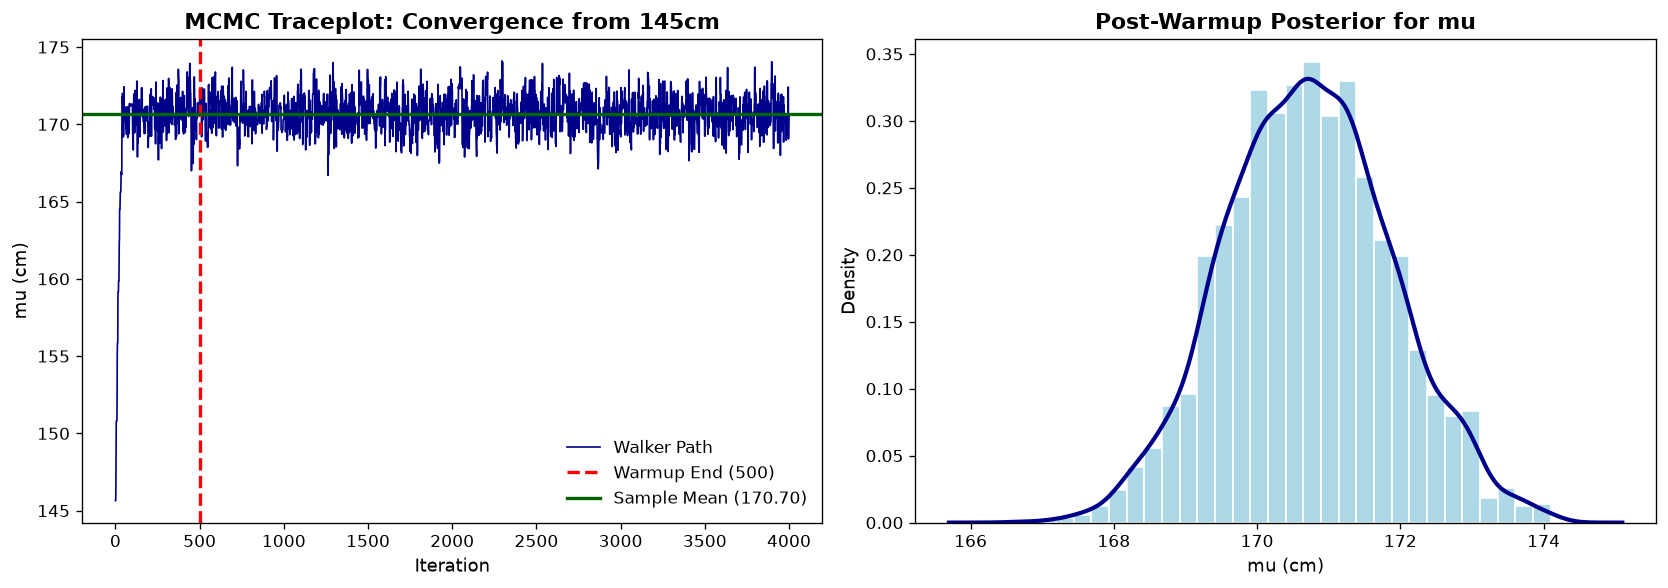

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)
n = 50
heights = np.random.normal(loc=172.5, scale=8.0, size=n)

# Target unnormalized log-posterior for mu (assuming fixed sigma = 8.0)
def target_log_posterior_mu(mu):
    # Likelihood: sum of log normal pdfs
    log_lik = np.sum(stats.norm.logpdf(heights, loc=mu, scale=8.0))
    # Prior: mu ~ Normal(170, 15)
    log_prior = stats.norm.logpdf(mu, loc=170, scale=15)
    return log_lik + log_prior

# Single Metropolis Step
def metropolis_step(current_mu, step_size=2.0):
    # Step 1: Propose candidate
    proposed_mu = current_mu + np.random.normal(loc=0, scale=step_size)
    
    # Step 2: Ratio in log-space
    log_alpha = target_log_posterior_mu(proposed_mu) - target_log_posterior_mu(current_mu)
    
    # Step 3: Coin flip
    if np.log(np.random.uniform(0, 1)) < log_alpha:
        return proposed_mu, True
    else:
        return current_mu, False

# Run full Markov Chain
def run_1d_mcmc(n_steps=4000, start_mu=145, step_size=2.0):
    samples = np.zeros(n_steps)
    accepted = 0
    curr = start_mu
    
    for t in range(n_steps):
        curr, was_accepted = metropolis_step(curr, step_size=step_size)
        if was_accepted:
            accepted += 1
        samples[t] = curr
        
    return samples, accepted / n_steps

# Execute walker starting far away at mu = 145 cm
fit_samples, accept_rate = run_1d_mcmc(n_steps=4000, start_mu=145, step_size=2.0)

print("=== 1D MCMC Run Results (Pure Python) ===")
print(f"Total Steps:     {len(fit_samples)}")
print(f"Acceptance Rate: {accept_rate * 100:.1f}%")
post_warmup = fit_samples[500:]
print(f"Posterior Mean:  {np.mean(post_warmup):.2f} cm (Discarding first 500 warmup steps)")
print(f"Posterior SD:    {np.std(post_warmup, ddof=1):.3f} cm")

# Visual inspection: Traceplot & Posterior Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

ax1.plot(fit_samples, color='darkblue', linewidth=1, label='Walker Path')
ax1.axvline(500, color='red', linestyle='--', linewidth=2, label='Warmup End (500)')
ax1.axhline(np.mean(heights), color='darkgreen', linewidth=2, label=f'Sample Mean ({np.mean(heights):.2f})')
ax1.set_title("MCMC Traceplot: Convergence from 145cm", fontsize=13, fontweight='bold')
ax1.set_xlabel("Iteration", fontsize=11)
ax1.set_ylabel("mu (cm)", fontsize=11)
ax1.legend(loc='lower right', frameon=False, fontsize=10)

ax2.hist(post_warmup, bins=30, density=True, color='lightblue', edgecolor='white')
kde_m = stats.gaussian_kde(post_warmup)
m_axis = np.linspace(post_warmup.min() - 1, post_warmup.max() + 1, 300)
ax2.plot(m_axis, kde_m(m_axis), color='darkblue', linewidth=2.5)
ax2.set_title("Post-Warmup Posterior for mu", fontsize=13, fontweight='bold')
ax2.set_xlabel("mu (cm)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)

plt.tight_layout()
plt.show()


## Part 4: The Step-Size ($\tau$) Dilemma & Tuning Failure Modes

The performance of a Metropolis sampler depends entirely on the proposal step size $\tau$:

1. **Step Size Too Small ($\tau = 0.1$)**: The proposal $\theta^*$ is so close to $\theta^{(t)}$ that $P(\theta^*) \approx P(\theta^{(t)})$, yielding an acceptance rate $> 95\%$. But the walker barely moves! It behaves like sluggish diffusion (high autocorrelation, slow exploration).
2. **Step Size Too Large ($\tau = 35.0$)**: The candidate $\theta^*$ lands far out in the low-probability tails. Almost every proposal is rejected ($< 2\%$ acceptance rate). The walker remains stuck on flatlines for hundreds of steps at a time.
3. **Optimal Step Size ($\tau = 2.5$)**: Balances exploration and acceptance, producing Gelman's optimal acceptance rate ($\sim 23.4\% - 44\%$ for random-walk Metropolis).

Let us simulate all three regimes side-by-side to witness these failure modes:

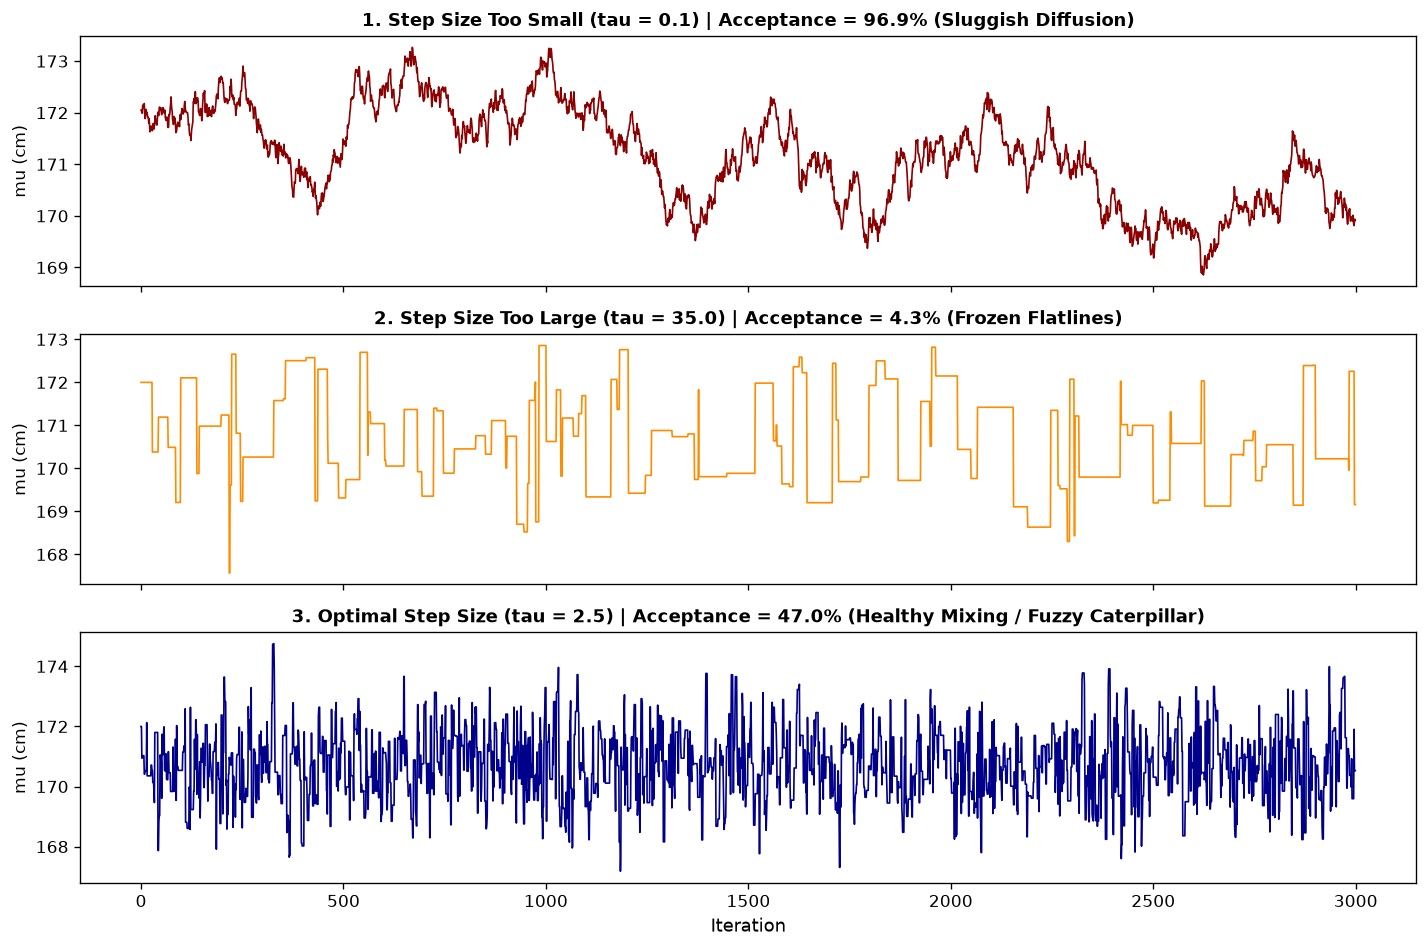

In [2]:
np.random.seed(42)
chain_tiny, acc_tiny = run_1d_mcmc(3000, start_mu=172, step_size=0.1)
chain_huge, acc_huge = run_1d_mcmc(3000, start_mu=172, step_size=35.0)
chain_ideal, acc_ideal = run_1d_mcmc(3000, start_mu=172, step_size=2.5)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), dpi=120, sharex=True)

axes[0].plot(chain_tiny, color='darkred', linewidth=1)
axes[0].set_title(f"1. Step Size Too Small (tau = 0.1) | Acceptance = {acc_tiny*100:.1f}% (Sluggish Diffusion)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("mu (cm)", fontsize=10)

axes[1].plot(chain_huge, color='darkorange', linewidth=1)
axes[1].set_title(f"2. Step Size Too Large (tau = 35.0) | Acceptance = {acc_huge*100:.1f}% (Frozen Flatlines)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("mu (cm)", fontsize=10)

axes[2].plot(chain_ideal, color='darkblue', linewidth=1)
axes[2].set_title(f"3. Optimal Step Size (tau = 2.5) | Acceptance = {acc_ideal*100:.1f}% (Healthy Mixing / Fuzzy Caterpillar)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("mu (cm)", fontsize=10)
axes[2].set_xlabel("Iteration", fontsize=11)

plt.tight_layout()
plt.show()


## Part 5: Autocorrelation, Markov Memory Decay & Effective Sample Size ($ESS$)

### Deep Dive 4: What is Autocorrelation in Markov Chains?

In Grid approximation (Sheet 1) or Laplace approximation (Sheet 2), every sample drawn is **statistically independent (i.i.d.)**. If you draw 10,000 samples, you have 10,000 completely independent pieces of information.

In MCMC, consecutive samples are **dependent** because $\theta^{(t+1)}$ starts where $\theta^{(t)}$ was. The **Autocorrelation at lag $k$** measures this memory:
$$\rho_k = \text{Cor}\left(\theta^{(t)}, \theta^{(t+k)}\right)$$

- In a healthy chain, $\rho_k$ decays exponentially to 0 as lag $k$ increases.
- In a sluggish chain (small step size), $\rho_k$ remains high even at lag 30!

### Effective Sample Size ($ESS$)
Due to autocorrelation, $N = 3000$ MCMC iterations does **not** equal 3000 independent samples. The **Effective Sample Size ($ESS$)** tells you how many independent samples your chain is worth:
$$ESS = \frac{N}{1 + 2 \sum_{k=1}^\infty \rho_k}$$

Let us plot the autocorrelation functions (autocorrelation analysis) and compute the $ESS$ for our small vs optimal chains:

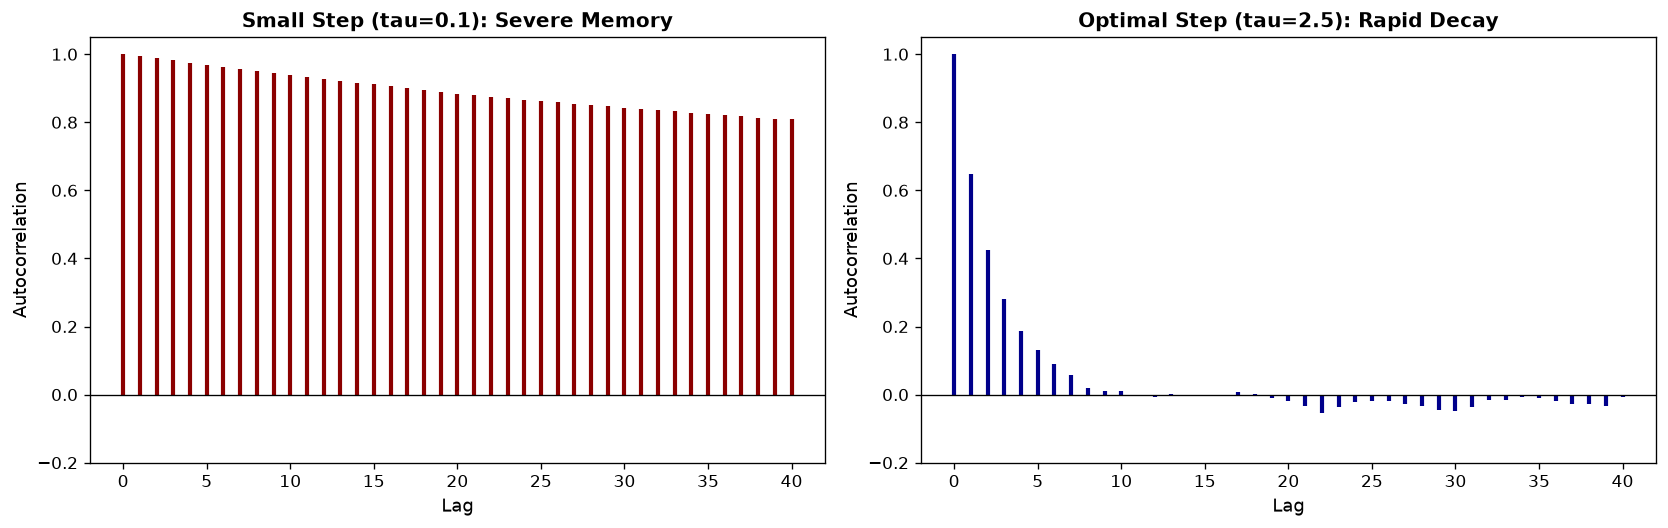

=== Effective Sample Size (ESS) Comparison (N = 3000 total iterations) ===
Small Step (tau = 0.1):  Lag-1 Cor = 0.994 | Approx ESS = 9 (Massive information loss!)
Optimal Step (tau = 2.5): Lag-1 Cor = 0.648 | Approx ESS = 641 (High information efficiency!)


In [3]:
def compute_autocorr(x, max_lag=40):
    x_c = x - np.mean(x)
    var = np.var(x)
    n = len(x)
    acf = np.correlate(x_c, x_c, mode='full')[n-1:n+max_lag] / (n * var)
    return acf

acf_tiny = compute_autocorr(chain_tiny, max_lag=40)
acf_ideal = compute_autocorr(chain_ideal, max_lag=40)
lags = np.arange(41)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), dpi=120)

ax1.vlines(lags, 0, acf_tiny, color='darkred', linewidth=2.5)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title("Small Step (tau=0.1): Severe Memory", fontsize=12, fontweight='bold')
ax1.set_xlabel("Lag", fontsize=11)
ax1.set_ylabel("Autocorrelation", fontsize=11)
ax1.set_ylim(-0.2, 1.05)

ax2.vlines(lags, 0, acf_ideal, color='darkblue', linewidth=2.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title("Optimal Step (tau=2.5): Rapid Decay", fontsize=12, fontweight='bold')
ax2.set_xlabel("Lag", fontsize=11)
ax2.set_ylabel("Autocorrelation", fontsize=11)
ax2.set_ylim(-0.2, 1.05)

plt.tight_layout()
plt.show()

# Estimate approximate ESS based on lag-1 autocorrelation: N * (1 - rho1) / (1 + rho1)
rho1_tiny = acf_tiny[1]
rho1_ideal = acf_ideal[1]

ess_tiny = len(chain_tiny) * (1 - rho1_tiny) / (1 + rho1_tiny)
ess_ideal = len(chain_ideal) * (1 - rho1_ideal) / (1 + rho1_ideal)

print("=== Effective Sample Size (ESS) Comparison (N = 3000 total iterations) ===")
print(f"Small Step (tau = 0.1):  Lag-1 Cor = {rho1_tiny:.3f} | Approx ESS = {int(round(ess_tiny))} (Massive information loss!)")
print(f"Optimal Step (tau = 2.5): Lag-1 Cor = {rho1_ideal:.3f} | Approx ESS = {int(round(ess_ideal))} (High information efficiency!)")


## Part 6: Joint 2D Metropolis from Scratch: Estimating Mean ($\mu$) and Spread ($\sigma$)

Now let us expand our Python sampler to jointly explore the 2D parameter space $(\mu, \sigma)$ simultaneously without any external packages!

=== 2D Metropolis-Hastings Results (Post-Warmup) ===
Acceptance Rate:        81.1%
Posterior Mean (mu):    170.75 cm (SD: 1.169 cm)
Posterior Mean (sigma): 7.61 cm (SD: 0.759 cm)
95% Credible (mu):      [168.41, 173.04] cm
95% Credible (sigma):   [6.29, 9.28] cm


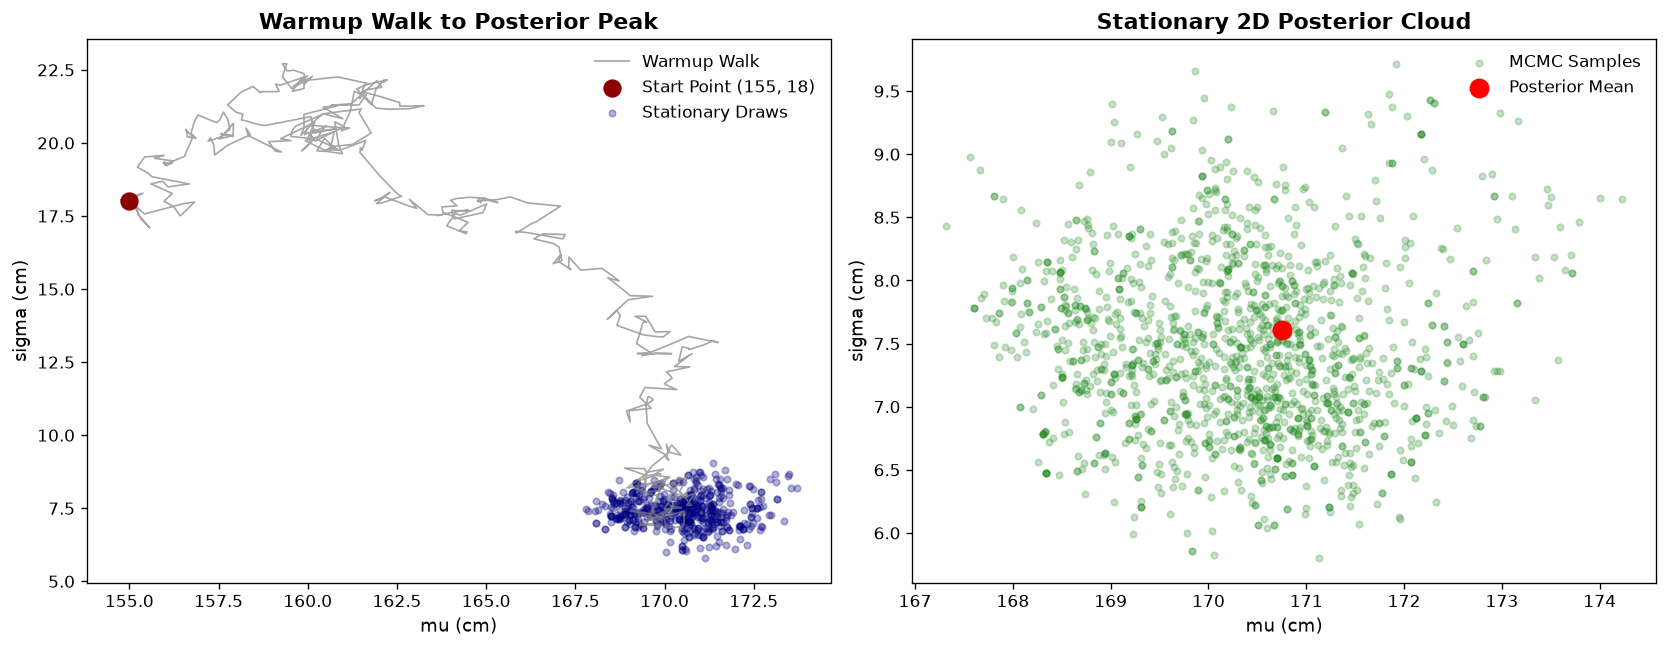

In [4]:
np.random.seed(42)

# Joint Log-Posterior for (mu, sigma)
def joint_log_post(mu, sigma):
    if sigma <= 0 or sigma >= 30:
        return -np.inf
    log_lik = np.sum(stats.norm.logpdf(heights, loc=mu, scale=sigma))
    log_prior = stats.norm.logpdf(mu, loc=170, scale=15) + stats.uniform.logpdf(sigma, loc=0, scale=30)
    return log_lik + log_prior

# 2D Random Walk Metropolis
def run_2d_mcmc(n_steps=8000, start_mu=155, start_sigma=18, step_sizes=(0.4, 0.3)):
    chain = np.zeros((n_steps, 2))
    mu, sigma = start_mu, start_sigma
    curr_log_p = joint_log_post(mu, sigma)
    accepts = 0
    
    for t in range(n_steps):
        prop_mu = mu + np.random.normal(0, step_sizes[0])
        prop_sigma = sigma + np.random.normal(0, step_sizes[1])
        
        prop_log_p = joint_log_post(prop_mu, prop_sigma)
        log_alpha = prop_log_p - curr_log_p
        
        if np.log(np.random.uniform(0, 1)) < log_alpha:
            mu, sigma = prop_mu, prop_sigma
            curr_log_p = prop_log_p
            accepts += 1
            
        chain[t] = [mu, sigma]
        
    return chain, accepts / n_steps

chain_2d, accept_rate_2d = run_2d_mcmc(n_steps=8000, start_mu=155, start_sigma=18)
post_samples = chain_2d[1000:] # Discard 1000 warmup steps

print("=== 2D Metropolis-Hastings Results (Post-Warmup) ===")
print(f"Acceptance Rate:        {accept_rate_2d * 100:.1f}%")
print(f"Posterior Mean (mu):    {np.mean(post_samples[:, 0]):.2f} cm (SD: {np.std(post_samples[:, 0], ddof=1):.3f} cm)")
print(f"Posterior Mean (sigma): {np.mean(post_samples[:, 1]):.2f} cm (SD: {np.std(post_samples[:, 1], ddof=1):.3f} cm)")
q_mu_2d = np.percentile(post_samples[:, 0], [2.5, 97.5])
q_sig_2d = np.percentile(post_samples[:, 1], [2.5, 97.5])
print(f"95% Credible (mu):      [{q_mu_2d[0]:.2f}, {q_mu_2d[1]:.2f}] cm")
print(f"95% Credible (sigma):   [{q_sig_2d[0]:.2f}, {q_sig_2d[1]:.2f}] cm")

# Visualizing 2D Trajectory and Joint Posterior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

ax1.plot(chain_2d[:500, 0], chain_2d[:500, 1], color='gray', alpha=0.7, linewidth=1, label='Warmup Walk')
ax1.scatter(155, 18, color='darkred', s=100, zorder=5, label='Start Point (155, 18)')
ax1.scatter(post_samples[:500, 0], post_samples[:500, 1], color='navy', alpha=0.3, s=15, label='Stationary Draws')
ax1.set_title("Warmup Walk to Posterior Peak", fontsize=13, fontweight='bold')
ax1.set_xlabel("mu (cm)", fontsize=11)
ax1.set_ylabel("sigma (cm)", fontsize=11)
ax1.legend(loc='upper right', frameon=False, fontsize=10)

ax2.scatter(post_samples[:1500, 0], post_samples[:1500, 1], color='forestgreen', alpha=0.25, s=15, label='MCMC Samples')
ax2.scatter(np.mean(post_samples[:, 0]), np.mean(post_samples[:, 1]), color='red', s=120, zorder=5, label='Posterior Mean')
ax2.set_title("Stationary 2D Posterior Cloud", fontsize=13, fontweight='bold')
ax2.set_xlabel("mu (cm)", fontsize=11)
ax2.set_ylabel("sigma (cm)", fontsize=11)
ax2.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


## Part 7: The Curse of Volume & The Leap to Hamiltonian Monte Carlo (HMC)

Our from-scratch Random Walk Metropolis worked beautifully for 2 parameters. But as we scale to modern scientific models (100–10,000 parameters), random walks suffer from a catastrophic geometric bottleneck called **the curse of volume**.

- In high dimensions, random walks almost always step in directions that **drop off the typical set** into near-zero probability space, forcing acceptance rates to drop to zero unless step sizes are microscopically small.
- Exploring a high-dimensional space with random walk diffusion requires $O(D^2)$ steps—it takes forever!

### The Solution: Sheet 4 and Hamiltonian Monte Carlo (Stan)
In **Sheet 4**, we replace blind random walks with **Hamiltonian Monte Carlo (HMC)**. Instead of staggering around blindly like a drunkard, HMC treats the negative log-posterior like a physical bowl and launches a frictionless particle that glides effortlessly along the contours of the typical set using Newton's laws of motion!

## Part 8: Hands-On Challenge Exercises

### Exercise 1: Asymmetric Proposals & The Hastings Correction
If your proposal distribution $q(\theta^* \mid \theta^{(t)})$ is asymmetric (e.g. proposing positive values only using a Log-Normal distribution), detailed balance requires the **Hastings correction factor**:
$$\alpha = \min\left(1, \; \frac{P(\theta^* \mid y)}{P(\theta^{(t)} \mid y)} \times \frac{q(\theta^{(t)} \mid \theta^*)}{q(\theta^* \mid \theta^{(t)})}\right)$$
- Explain why this correction factor equals $1.0$ when the proposal distribution is Gaussian $\text{Normal}(\theta, \tau^2)$. *(Hint: Gaussian density is symmetric around its mean: $dnorm(x - y) = dnorm(y - x)$)*.

### Exercise 2: Thinning the Chain
Take `chain_tiny$samples` (high autocorrelation) and thin it by retaining only every 10th sample: `thinned_samples <- chain_tiny$samples[seq(1, length(chain_tiny$samples), by = 10)]`.
- Plot `acf(thinned_samples)`. What happened to the lag-1 autocorrelation?
- Did thinning increase the amount of information in the chain? *(Hint: No, discarding data never adds new information; thinning only reduces memory usage when saving millions of draws to disk)*.

---

**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 2 (Quadratic Approx)](02_quadratic_laplace_approximation.ipynb) | [➡️ Next: Sheet 4 (Production MCMC)](04_mcmc_production_diagnostics.ipynb)